# Кластерный анализ методом k-means
## Датасет: flame

## 1. Кластерный анализ k-means для k=2


Применяем алгоритм k-means с заданным числом кластеров `k=2`. Алгоритм
итеративно назначает каждую точку ближайшему центроиду и пересчитывает
центроиды до сходимости, минимизируя суммарное квадратичное отклонение
точек от центров своих кластеров.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

#загружаем данные из файла 'flame.txt'. 
#sep='\t' означает, что колонки в файле разделены табуляцией
df = pd.read_csv('flame.txt', sep='\t')
#берем из таблицы только столбцы с координатами 'x1' и 'x2' и превращаем их в массив чисел
X = df[['x1', 'x2']].values
#сохраняем настоящие ответы (правильные метки классов) в отдельную переменную 
#это нужно, чтобы потом сравнить: угадал алгоритм или нет
y_true = df['class'].values
#создаем объект алгоритма k-means, n_clusters=2 - говорим ему искать ровно 2 группы
#random_state=42 - фиксируем случайность, чтобы результат был одинаковым при каждом запуске
#n_init=10 - запускаем процесс подбора 10 раз с разными стартовыми точками и выбираем лучший вариант
km2 = KMeans(n_clusters=2, random_state=42, n_init=10) 
#обучаем алгоритм на наших данных (X) и сразу просим его разметить точки. результат (кто к какой группе относится) сохраняем в labels2
labels2 = km2.fit_predict(X)
#выводим на экран координаты центров найденных групп
print(f"Центроиды:\n{km2.cluster_centers_}")
#выводим инерцию - это сумма квадратов расстояний от точек до центров их групп. чем число меньше, тем кучнее сгруппированы точки
print(f"Инерция: {km2.inertia_:.2f}")

Центроиды:
[[ 8.83690476 18.58571429]
 [ 5.65131579 23.51798246]]
Инерция: 3123.77


### Вывод по этапу
Алгоритм поставил два условных центроида и начал бегать вокруг точек, чтобы понять, какая из них ближе к какому центроиду, повторяя это действие 10 раз, пока результат не стабилизировался. В итоге он вывел координаты этих центроидов ([ 8.83690476 18.58571429] и [ 5.65131579 23.51798246]) и число 3123.77 - это инерция. Чем меньше инерция, тем плотнее сгруппированы точки внутри кластеров.

## 2. Раскрашенная диаграмма кластеров


Визуализация позволяет наглядно сравнить результат кластеризации с истинной
разметкой и увидеть, где алгоритм k-means ошибся.

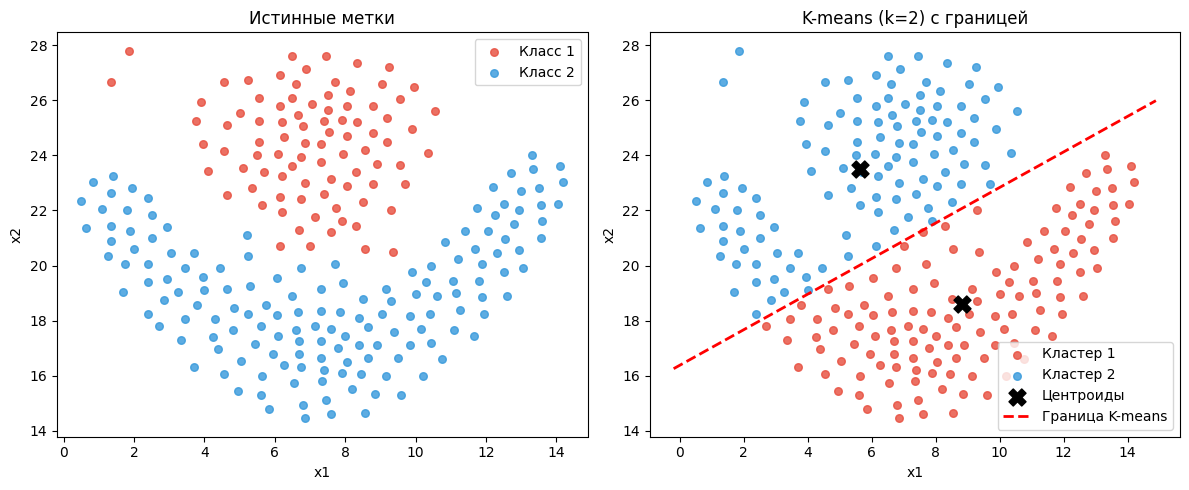

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
clrs = ['#e74c3c', '#3498db']

#левый графимк: истинные метки
for cls, col in [(1, '#e74c3c'), (2, '#3498db')]:
    mask = y_true == cls
    axes[0].scatter(X[mask, 0], X[mask, 1], c=col, s=30, alpha=0.8, label=f'Класс {cls}')
axes[0].set_title('Истинные метки')
axes[0].legend()
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')

#правый график: K-means с границей
#1. рисуем точки кластеров
for i in range(2):
    mask = labels2 == i
    axes[1].scatter(X[mask, 0], X[mask, 1], c=clrs[i], s=30, alpha=0.8, label=f'Кластер {i+1}')

#2. рисуем центроиды (черные крестики)
centers = km2.cluster_centers_
axes[1].scatter(centers[:, 0], centers[:, 1],
                c='black', marker='X', s=150, zorder=5, label='Центроиды')

#3. рисуем границу решения (Decision Boundary)
#граница проходит перпендикулярно отрезку между центрами и через его середину.
c1, c2 = centers[0], centers[1]

#находим среднюю точку между центроидами
mid_point = (c1 + c2) / 2

#находим вектор, соединяющий центроиды
vec = c2 - c1

#если вектор не нулевой, строим линию
if np.linalg.norm(vec) > 0:
    #наклон исходной линии (между центрами)
    #k_line = vec[1] / vec[0]
    #наклон перпендикуляра (границы) будет -1 / k_line
    #но проще использовать уравнение прямой через нормаль:
    #vec[0]*(x - mid_x) + vec[1]*(y - mid_y) = 0
    
    #выразим y через x для построения графика:
    #vec[1]*y = -vec[0]*(x - mid_x) + vec[1]*mid_y ... немного упростим
    
    #берем крайние точки графика по оси X
    x_min, x_max = axes[1].get_xlim()
    #если график еще не отрендерен, берем мин/макс данных
    if x_min == 0 and x_max == 1: 
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        
    #уравнение границы: vec[0]*x + vec[1]*y = C, где C = vec[0]*mid_x + vec[1]*mid_y
    #y = (C - vec[0]*x) / vec[1]
    
    #обработка случая, когда vec[1] близко к 0 (вертикальная граница)
    if abs(vec[1]) < 1e-6:
        #вертикальная линия
        axes[1].axvline(x=mid_point[0], color='red', linestyle='--', linewidth=2, label='Граница K-means')
    else:
        C = np.dot(vec, mid_point)
        y_boundary = (C - vec[0] * np.array([x_min, x_max])) / vec[1]
        axes[1].plot([x_min, x_max], y_boundary, 'r--', linewidth=2, label='Граница K-means')

axes[1].set_title(f'K-means (k=2) с границей')
axes[1].legend()
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2')

plt.tight_layout()
plt.show()

### Вывод по этапу
В результате есть два графика:

Слева: Так как точки распределены на самом деле (истина). Там видно две изогнутые фигуры, похожие на языки пламени.


Справа: Так как их разложил алгоритм K-means.


Видно, что k-means делит точки границей
по центру масс, тогда как истинная граница между двумя «языками пламени»
нелинейная. Алгоритм неверно классифицирует точки в зоне перекрытия классов -
часть верхнего языка попадает в нижний кластер и наоборот.

## 3. Кластерные силуэты и оценка качества


Силуэт количественно оценивает качество кластеризации. Для каждой точки
вычисляется:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\ b(i))}$$

где:
- `a(i)` - среднее расстояние от точки до остальных точек своего кластера
- `b(i)` - среднее расстояние от точки до точек ближайшего чужого кластера

Значение `s(i)` ∈ [-1, 1]. Чем ближе к 1 - тем увереннее точка принадлежит
своему кластеру. Отрицательные значения означают, что точка скорее всего
попала не в тот кластер.

Индекс силуэта: 0.3785


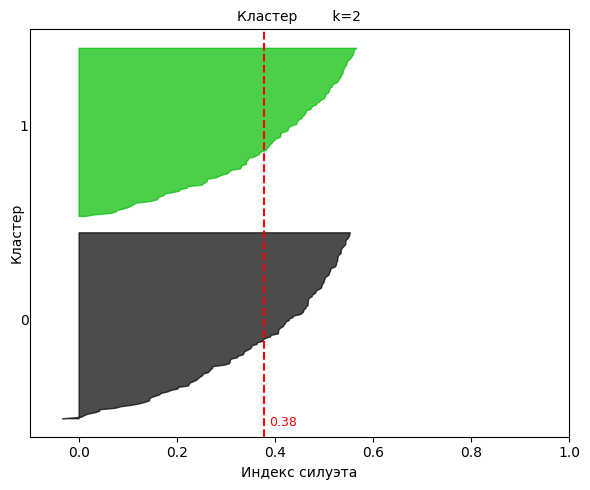

In [ ]:
#вычисляем силуэт для каждой отдельной точки, чтобы понять,
#насколько хорошо она «сидит» в своём кластере
sample_silhouette_values = silhouette_samples(X, labels2)
#считаем средний индекс силуэта по всем точкам
#это общая оценка качества разбиения (от -1 до 1)
avg_score = silhouette_score(X, labels2)

print(f"Индекс силуэта: {avg_score:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
y_lower = 10
#проходимся по каждому из двух найденных кластеров
for i in range(2):
    ith = sample_silhouette_values[labels2 == i]
    ith.sort()
    y_upper = y_lower + ith.shape[0]
    color = cm.nipy_spectral(float(i) / 2)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.12, y_lower + 0.5 * ith.shape[0], str(i))
    y_lower = y_upper + 10

ax.axvline(x=avg_score, color='red', linestyle='--')
ax.text(avg_score + 0.01, 5, f'{avg_score:.2f}', color='red', fontsize=9)
ax.set_title(f'Кластер        k=2', fontsize=10)
ax.set_xlabel('Индекс силуэта')
ax.set_ylabel('Кластер')
ax.set_yticks([])
ax.set_xlim(-0.1, 1.0)
plt.tight_layout()
plt.show()

### Вывод по этапу
При `k=2` средний индекс силуэта составил 0.38 - это низкая оценка, которая говорит о плохом качестве разбиения.

На силуэтном графике видно, что кластер 0 имеет много точек с низкими
значениями силуэта - полоса резко сужается к нулю и уходит в отрицательную
зону. Это означает, что значительная часть точек находится ближе к чужому
кластеру, чем к своему. Кластер 1 выглядит чуть лучше, но тоже далек
от идеала.

## 4. Ответы на вопросы

### Справился ли алгоритм k-means с датасетом flame?

Нет, алгоритм не справился.

При `k=2` алгоритм разбивает данные по геометрическому центру, тогда как
реальная граница между классами нелинейная. Значительная часть точек
оказывается в «неправильном» кластере. Индекс силуэта 0.38 подтверждает
слабое качество разбиения - структура «слабая». То есть алгоритм разбил данные пополам, игнорируя их истинную форму.

### Какие ограничения k-means помешали?

1. Гипотеза о компактности («сферические сгустки»)

Главное ограничение. K-means минимизирует евклидово расстояние от точек до
центроидов, что неявно предполагает сферическую форму кластеров. То есть алгоритм ожидает группы в виде круглых пятен или сфер, когда данные
flame имеют вытянутую, изогнутую форму, поэтому алгоритм физически не способен
построить такую границу между кластерами.

2. Равенство размеров кластеров

k-means старается разбивать на примерно равные по числу точек группы.
В датасете классы несбалансированы (87 и 153), и алгоритм стремится
«компенсировать» это, перераспределяя точки вопреки истинной принадлежности.

3. Чувствительность к начальной конфигурации

При нечёткой структуре результат сильно зависит от случайной инициализации
центроидов. Даже `n_init=10` не гарантирует нахождение содержательного
разбиения, так как форма данных не подходит для этого алгоритма.